<a href="https://colab.research.google.com/github/sohampatilakl/Disease-Risk-Prediction-Diabetes-/blob/main/Code_of_Disease_Risk_Predictor_(Diabetes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the full dataset
file_path = "/content/diabetes_prediction_india (1).csv"
df = pd.read_csv(file_path)

# 2. Handle missing data (Fill missing Alcohol_Intake with 'None')
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('None')

# 3. Separate Features (X_raw) and Target (y)
X_raw = df.drop('Diabetes_Status', axis=1)
y_raw = df['Diabetes_Status']

# Convert the Target column to 1 (Yes) and 0 (No)
y = y_raw.map({'Yes': 1, 'No': 0})

# 4. One-Hot Encoding for the machine learning model
# This transforms all text-based lifestyle columns into numerical features
X = pd.get_dummies(X_raw, drop_first=True)
training_columns = X.columns

# 5. Create the "Population Baseline"
# We calculate the median for numerical data and mode for text data.
# This acts as a default template for when our at-home user doesn't know a medical answer.
baseline_profile = {}
for col in X_raw.columns:
    if pd.api.types.is_numeric_dtype(X_raw[col]):
        baseline_profile[col] = X_raw[col].median()
    else:
        baseline_profile[col] = X_raw[col].mode()[0]

print(f"✅ Full dataset loaded. Model will train on {len(training_columns)} features.")
display(X.head(3))

✅ Full dataset loaded. Model will train on 33 features.


,Age,BMI,Cholesterol_Level,Fasting_Blood_Sugar,Postprandial_Blood_Sugar,HBA1C,Heart_Rate,Waist_Hip_Ratio,Pregnancies,Glucose_Tolerance_Test_Result,...,Stress_Level_Low,Stress_Level_Medium,Hypertension_Yes,Urban_Rural_Urban,Health_Insurance_Yes,Regular_Checkups_Yes,Medication_For_Chronic_Conditions_Yes,Polycystic_Ovary_Syndrome_No,Polycystic_Ovary_Syndrome_Yes,Thyroid_Condition_Yes
0,48,35.5,111.7,141.0,165.6,8.9,94,0.91,0,124.3,...,False,True,True,True,False,False,False,False,False,True
1,18,28.7,130.6,83.1,142.6,5.9,68,0.96,0,151.4,...,False,False,False,False,True,True,False,False,False,True
2,21,30.0,294.8,159.9,212.4,4.8,70,0.88,0,106.1,...,False,False,True,False,False,False,True,False,False,False


=== Model Training Complete ===
Random Forest F1-Score: 67.0%



/tmp/ipykernel_1127/3190655687.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


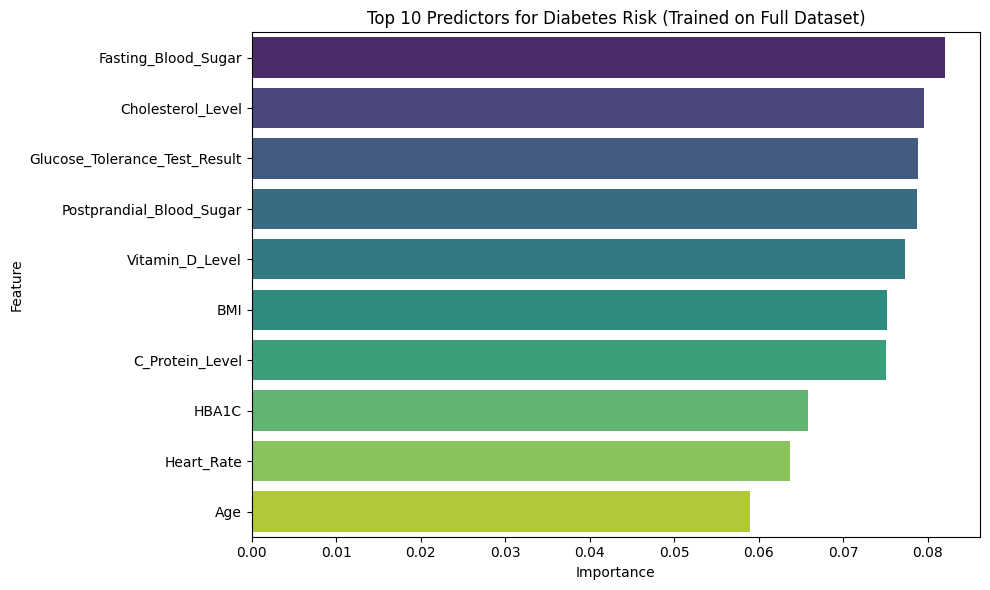

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# 1. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Standardize all 27+ numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Models
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 4. Evaluate Threshold for Recall/F1
y_pred_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
custom_threshold = 0.45
y_pred_custom = (y_pred_probs >= custom_threshold).astype(int)

print("=== Model Training Complete ===")
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_custom) * 100:.1f}%\n")

# 5. Extract and Plot Top Feature Importances
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': training_columns, 'Importance': importances})
top_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Predictors for Diabetes Risk (Trained on Full Dataset)')
plt.tight_layout()
plt.show()

In [ ]:
def at_home_smart_screener():
    print("=" * 55)
    print(" 📱 AT-HOME DIABETES RISK SCREENER (Powered by AI)")
    print("=" * 55)
    print("Answer a few basic questions. Our system will fill in the")
    print("complex medical gaps using population trends.\n")

    try:
        # 1. Ask everyday, non-medical questions
        age = float(input("1. What is your age? "))
        gender = input("2. Gender (Male/Female): ").strip().title()
        weight = float(input("3. What is your body weight (in kg)? "))
        height = float(input("4. What is your height (in meters, e.g. 1.75)? "))

        fam_hist_input = input("5. Do your parents have diabetes? (yes/no): ").strip().lower()
        family_history = 'Yes' if fam_hist_input in ['yes', 'y'] else 'No'

        hyper_input = input("6. Do you have high blood pressure? (yes/no): ").strip().lower()
        hypertension = 'Yes' if hyper_input in ['yes', 'y'] else 'No'

        glucose_input = input("7. Fasting blood sugar? (Enter number, or press Enter if unknown): ")
        glucose = float(glucose_input) if glucose_input else baseline_profile['Fasting_Blood_Sugar']

        # Calculate BMI
        bmi = weight / (height ** 2)

        # 2. Build the Complete Profile
        # Start with the default template of all 27 columns
        user_profile = baseline_profile.copy()

        # Overwrite the defaults with the specific user inputs
        user_profile['Age'] = age
        user_profile['Gender'] = gender if gender in ['Male', 'Female'] else 'Other'
        user_profile['BMI'] = bmi
        user_profile['Family_History'] = family_history
        user_profile['Hypertension'] = hypertension
        user_profile['Fasting_Blood_Sugar'] = glucose

        # 3. Transform to ML format
        # Convert dictionary to DataFrame
        user_df = pd.DataFrame([user_profile])

        # Apply One-Hot Encoding
        user_encoded = pd.get_dummies(user_df)

        # Align columns with the training set (fills missing categories with 0)
        # This is critical so the model receives the exact number of columns it expects
        user_encoded = user_encoded.reindex(columns=training_columns, fill_value=0)

        # Scale the data using the pre-fitted scaler
        user_scaled = scaler.transform(user_encoded)

        # 4. Predict
        risk_probability = rf_model.predict_proba(user_scaled)[0][1] * 100

        # 5. Output Friendly Results
        print("\n" + "=" * 55)
        print(" 📊 YOUR RESULTS")
        print("=" * 55)
        print(f"Calculated BMI : {bmi:.1f}")
        print(f"Risk Score     : {risk_probability:.1f}%")
        print("-" * 55)

        if risk_probability >= 50.0:
            print("🚨 High Risk: We strongly recommend scheduling a checkup with a doctor.")
        elif risk_probability >= 30.0:
            print("⚠️ Moderate Risk: You may be in the pre-diabetic range. Focus on diet and exercise.")
        else:
            print("✅ Low Risk: Keep up the healthy lifestyle!")
        print("=" * 55)

    except ValueError:
        print("\n❌ Input Error: Please enter valid numbers (e.g., 75 for weight).")

# Run the smart interface
at_home_smart_screener()

 📱 AT-HOME DIABETES RISK SCREENER (Powered by AI)
Answer a few basic questions. Our system will fill in the
complex medical gaps using population trends.

1. What is your age? 15
2. Gender (Male/Female): Male
3. What is your body weight (in kg)? 57
4. What is your height (in meters, e.g. 1.75)? 1.5
5. Do your parents have diabetes? (yes/no): no
6. Do you have high blood pressure? (yes/no): yes
7. Fasting blood sugar? (Enter number, or press Enter if unknown): 

 📊 YOUR RESULTS
Calculated BMI : 25.3
Risk Score     : 49.9%
-------------------------------------------------------
⚠️ Moderate Risk: You may be in the pre-diabetic range. Focus on diet and exercise.
